# Sentiment Analysis with BERT

State-of-the-art sentiment analysis typically doesn’t rely on bag-of-words models trained from scratch. Instead, it uses BERT models fine-tuned on sentiment-analysis datasets. Fine-tuning is accomplished by further training a pretrained model for a limited number of epochs and with a reduced learning rate. Let’s fine-tune BERT and see if we can create a sentiment-analysis model that’s more accurate than a from-scratch model. If your computer isn’t equipped with a GPU, consider running this example in [Google Colab](https://colab.research.google.com/). Even on GPU, it can take an hour or so to run – depending on the type of GPU, of course.

This lab requires TensorFlow and Hugging Face's [`transformers`](https://pypi.org/project/transformers/) package, so if you're running the code locally, make sure both are installed. Colab already has everything you need. Start by loading the dataset:

In [1]:
import pandas as pd

df = pd.read_csv('Data/reviews.csv', encoding="ISO-8859-1")
df = df.sample(frac=1, random_state=0)
df.head()

,Text,Sentiment
11841,Al Pacino was once an actor capable of making ...,0
19602,After Chaplin made one of his best films: Doug...,0
45519,This movie is sort of a Carrie meets Heavy Met...,1
25747,I have fond memories of watching this visually...,1
42642,"In the '70s, Charlton Heston starred in sci-fi...",1


Remove duplicate rows and check for balance.

In [2]:
df = df.drop_duplicates()
df.groupby('Sentiment').describe()

Text                                                            \
           count unique                                                top   
Sentiment                                                                    
0          24697  24697  What could've been a great film about the late...   
1          24884  24884  I really enjoyed this film. All aspects of the...   

                
          freq  
Sentiment       
0            1  
1            1

Split the dataset into two datasets: one for training and one for testing. Then create a tokenizer that tokenizes input text using the [WordPiece](https://huggingface.co/course/chapter6/6?fw=pt) format that BERT expects, create a tokenized training set and a tokenized validation set, and convert them into [TensorFlow datasets](https://www.tensorflow.org/api_docs/python/tf/data/Dataset).

In [3]:
import tensorflow as tf
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.5, random_state=42)
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(examples):
    return tokenizer(examples, truncation=True, padding=True, return_tensors='tf')

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(tokenize(train_df['Text'].tolist())),
    train_df['Sentiment'].values  # Labels
)).shuffle(len(train_df)).batch(16)

validation_dataset = tf.data.Dataset.from_tensor_slices((
    dict(tokenize(val_df['Text'].tolist())),
    val_df['Sentiment'].values  # Labels
)).batch(16)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Now you’re ready to fine-tune. Call `fit` on the model as usual, but set the `Adam` optimizer’s learning rate (the nominal amount that weights and biases are adjusted during backpropagation passes) to 0.00002, which is a fraction of the default learning rate of 0.001:

In [4]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

hist = model.fit(train_dataset, validation_data=validation_dataset, epochs=3)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
1550/1550 [==============================] - 275s 163ms/step - loss: 0.2493 - accuracy: 0.8987 - val_loss: 0.1821 - val_accuracy: 0.9300
Epoch 2/3
1550/1550 [==============================] - 229s 148ms/step - loss: 0.1317 - accuracy: 0.9526 - val_loss: 0.1985 - val_accuracy: 0.9271
Epoch 3/3
1550/1550 [==============================] - 227s 146ms/step - loss: 0.0690 - accuracy: 0.9764 - val_loss: 0.2116 - val_accuracy: 0.9251


Plot the training and validation accuracy to see where the latter topped out:

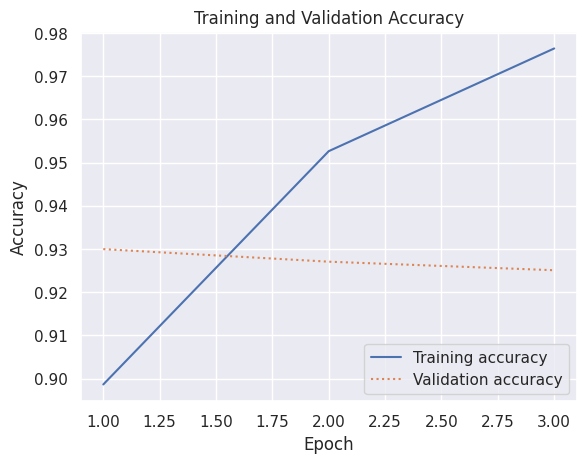

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

acc = hist.history['accuracy']
val = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, '-', label='Training accuracy')
plt.plot(epochs, val, ':', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

plt.savefig('sample_data/Inline 13-f.png', dpi=150)

## Use the model to analyze text

Finish up by defining an `analyze_text` function that returns a sentiment score and using it to score a positive review for sentiment. The model returns an object wrapping a tensor containing unnormalized sentiment scores (negative and positive), but you can use TensorFlow’s `softmax` function to normalize them to values from 0.0 to 1.0:

In [6]:
def analyze_text(text, tokenizer, model):
    tokenized_text = tokenizer(text, padding=True, truncation=True, return_tensors='tf')
    prediction = model(tokenized_text)
    return tf.nn.softmax(prediction[0]).numpy()[0][1]

analyze_text('Great food and excellent service', tokenizer, model)

0.9950572

Try it again with a negative review:

In [7]:
analyze_text('The long lines and poor customer service really turned me off', tokenizer, model)

0.032125164

Here's another negative review.

In [8]:
analyze_text('The food was bad, not great at all', tokenizer, model)

0.017601917

What happens if we swap two words and completely change the sentiment of the review?

In [9]:
analyze_text('The food was good, not bad at all', tokenizer, model)

0.70196396

Fine-tuning isn’t cheap, but it isn’t nearly as expensive as training a sophisticated transformer from scratch. The fact that you could train a sentiment-analysis model to be this accurate in an hour or less of GPU time is a tribute to the power of pretrained BERT models, and to the Google engineers who trained them.